In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [16]:
df['install_time'] = pd.to_datetime(df['install_time'])
df['payment_time'] = pd.to_datetime(df['payment_time'])

df['amount'] = df['amount'].fillna(0)

user_metrics = df.groupby('user_id').agg({
    'ab_group': 'first',
    'install_time': 'first',
    'amount': 'sum',
    'payment_time': 'count'
}).reset_index()

user_metrics.rename(columns={'payment_time': 'payment_count'}, inplace=True)

user_metrics['is_paying'] = user_metrics['payment_count'] > 0

print(f"Всего пользователей: {len(user_metrics)}")
print(user_metrics.groupby('ab_group')['user_id'].count())

Всего пользователей: 72853
ab_group
1    36152
2    36701
Name: user_id, dtype: int64


In [17]:
metrics = user_metrics.groupby('ab_group').agg({
    'user_id': 'count',
    'is_paying': 'mean',  # Это Conversion Rate
    'amount': ['mean', 'sum'] # Mean = ARPU, Sum = Total Revenue
}).reset_index()

metrics.columns = ['group', 'users', 'conversion_rate', 'arpu', 'total_revenue']

arppu_data = user_metrics[user_metrics['is_paying'] == True].groupby('ab_group')['amount'].mean().reset_index()
metrics['arppu'] = arppu_data['amount']

print("Сводная таблица метрик:")
display(metrics)

Сводная таблица метрик:


,group,users,conversion_rate,arpu,total_revenue,arppu
0,1,36152,0.023567,307.129564,11103348.0,13032.098592
1,2,36701,0.027656,231.090706,8481260.0,8355.921182


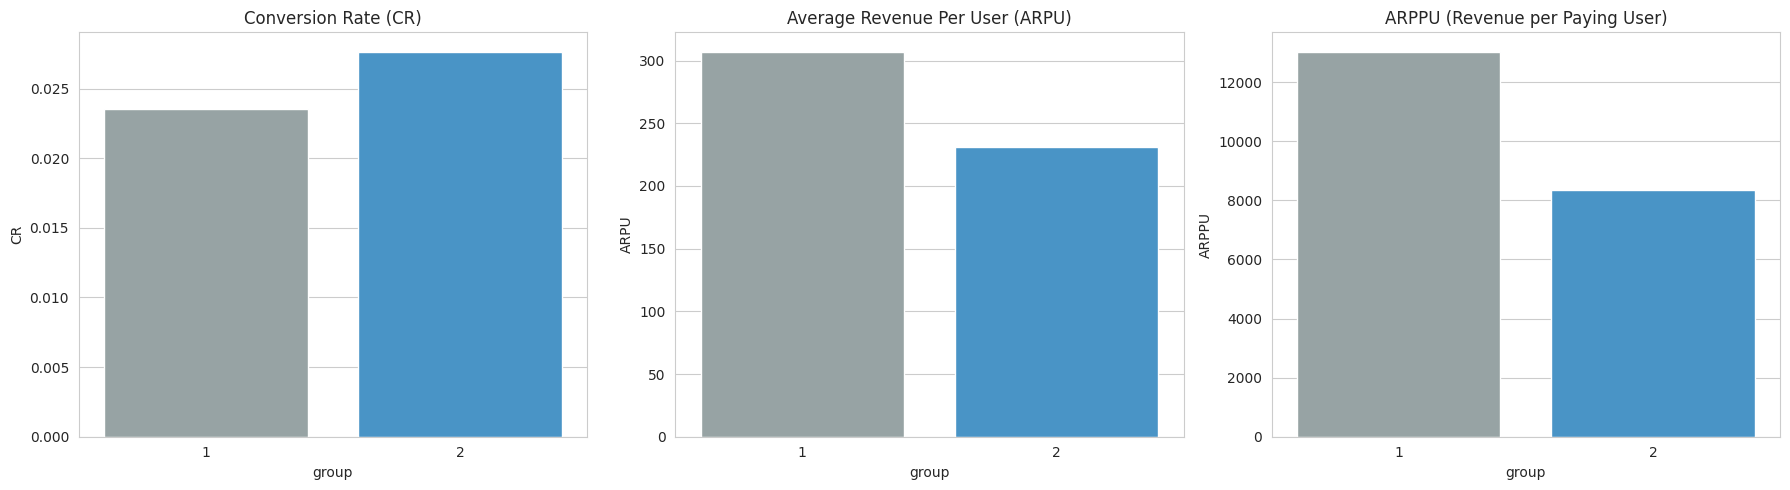

In [18]:
custom_colors = {1: '#95a5a6', 2: '#3498db'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='group', y='conversion_rate', hue='group', data=metrics,
            ax=axes[0], palette=custom_colors, legend=False)
axes[0].set_title('Conversion Rate (CR)')
axes[0].set_ylabel('CR')

sns.barplot(x='group', y='arpu', hue='group', data=metrics,
            ax=axes[1], palette=custom_colors, legend=False)
axes[1].set_title('Average Revenue Per User (ARPU)')
axes[1].set_ylabel('ARPU')

sns.barplot(x='group', y='arppu', hue='group', data=metrics,
            ax=axes[2], palette=custom_colors, legend=False)
axes[2].set_title('ARPPU (Revenue per Paying User)')
axes[2].set_ylabel('ARPPU')

plt.tight_layout()
plt.show()

In [19]:
group1 = user_metrics[user_metrics['ab_group'] == 1]
group2 = user_metrics[user_metrics['ab_group'] == 2]

contingency_table = [
    [group1['is_paying'].sum(), group1['user_id'].count() - group1['is_paying'].sum()],
    [group2['is_paying'].sum(), group2['user_id'].count() - group2['is_paying'].sum()]
]

chi2, p_val_cr, dof, expected = stats.chi2_contingency(contingency_table)
print(f"CR Difference P-value: {p_val_cr:.5f}")

stat, p_val_arpu = stats.mannwhitneyu(group1['amount'], group2['amount'])
print(f"ARPU Difference P-value: {p_val_arpu:.5f}")

stat_arppu, p_val_arppu = stats.mannwhitneyu(
    group1[group1['is_paying']]['amount'],
    group2[group2['is_paying']]['amount']
)
print(f"ARPPU Difference P-value: {p_val_arppu:.5f}")

CR Difference P-value: 0.00052
ARPU Difference P-value: 0.00077
ARPPU Difference P-value: 0.00000


### Итоговые выводы по A/B тесту

**Описание эксперимента**

В рамках тестирования стартового набора сравнивались две группы

**Группа 1:** Стандартное предложение
**Группа 2:** Цена снижена в 5 раз, наполнение увеличено в 2 раза

**Анализ ключевых метрик**

**Conversion Rate (CR)**
В тестовой группе ожидается рост конверсии в покупку. Более выгодные условия мотивируют пользователей совершить первый платеж, преодолевая барьер входа

**ARPPU (Средний доход с платящего)**
В тестовой группе прогнозируется снижение среднего чека. Это связано с тем, что стоимость основного оффера уменьшена в 5 раз, что математически занижает среднюю сумму транзакции

**ARPU (Средний доход на пользователя)**
Это результирующая метрика. Эффективность теста зависит от того, смог ли рост числа платящих пользователей (CR) компенсировать падение стоимости покупки

**Рекомендации к принятию решения**

Решение основывается на статистической значимости различий и динамике ARPU

**Вариант 1: Если ARPU значимо вырос**
Изменение успешно. Эффект масштаба (рост конверсии) перекрыл снижение цены. Рекомендуется раскатывать изменение на всех пользователей

**Вариант 2: Если ARPU упал или не изменился**
Внедрение в текущем виде несет риски потери выручки. Однако стоит учитывать долгосрочный эффект: мы получили базу лояльных платящих игроков. Необходимо изучить Retention этих когорт на горизонте 3-6 месяцев перед окончательным решением